In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


from xgboost import XGBRegressor
import xgboost as xgb
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
class EnergyReconstructor:
    def __init__(self, model_path=None, linear_params_path=None):
        self.params = {
            'n_estimators': 1000,
            'learning_rate': 0.03,
            'max_depth': 8,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'n_jobs': -1,
            'random_state': 42
        }
        self.model = xgb.XGBRegressor(**self.params)
        self.model._estimator_type = "regressor"
        self.linear_model = LinearRegression()
        
        if model_path:
            self.model.load_model(model_path)
        if linear_params_path:
            with open(linear_params_path, 'r') as f:
                p = json.load(f)
            self.linear_model.coef_     = np.array(p['coef'])
            self.linear_model.intercept_ = p['intercept']

    def load_and_preprocess(self, filepath):
        data = np.load(filepath, allow_pickle=True)
        df = pd.DataFrame(data['params'], columns=data['param_names'])
        
        cols_to_numeric = ['NuW3', 'rec_theta', 'dr', 'trueE']
        for col in cols_to_numeric:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        
        df = df[df['NuW3'] > 0].copy()
        df['log_NuW3'] = np.log10(df['NuW3'])
        
        threshold = 3.16e9
        df_low  = df[df['trueE'] <  threshold].sample(frac=0.2, random_state=42)
        df_high = df[df['trueE'] >= threshold]
        df_balanced = pd.concat([df_low, df_high], ignore_index=True)
        
        mask = (df_balanced['dr'] > 0) & \
               (df_balanced['rec_theta'] > 0) & \
               (df_balanced['rec_theta'] <= np.deg2rad(70))
        clean_df = df_balanced[mask].copy()
        
        X = clean_df[['log_NuW3', 'rec_theta']].values
        y = np.log10(clean_df['trueE'] / 1e8)
        
        return X, y, clean_df['trueE']

    def train(self, X, y,
              model_save_path   = "/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json",
              linear_save_path  = "/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json"):
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=99)
        
        # ── Step 1: 线性模型拟合全局趋势 ──────────────────────────
        print("Fitting linear baseline model...")
        self.linear_model.fit(X_train, y_train)
        
        y_linear_train = self.linear_model.predict(X_train)
        y_linear_test  = self.linear_model.predict(X_test)
        
        print(f"  Linear model coef  : log_NuW3={self.linear_model.coef_[0]:.6f}, "
              f"rec_theta={self.linear_model.coef_[1]:.6f}")
        print(f"  Linear model intercept: {self.linear_model.intercept_:.6f}")
        
        # ── Step 2: XGBoost 仅拟合残差 ────────────────────────────
        y_residual_train = y_train - y_linear_train
        
        print("Training XGBoost residual model...")
        self.model.fit(X_train, y_residual_train)
        
        # ── Step 3: 组合预测与评估 ────────────────────────────────
        y_residual_pred = self.model.predict(X_test)
        y_pred = y_linear_test + y_residual_pred        # ← 最终预测
        
        mae = mean_absolute_error(y_test, y_pred)
        r2  = r2_score(y_test, y_pred)
        
        # 与纯线性对比
        mae_lin = mean_absolute_error(y_test, y_linear_test)
        r2_lin  = r2_score(y_test, y_linear_test)
        
        print(f"\n[Pure Linear]   MAE: {mae_lin:.4f},  R²: {r2_lin:.4f}")
        print(f"[Linear + XGB]  MAE: {mae:.4f},  R²: {r2:.4f}  ← final model")
        
        # ── Step 4: 保存 ──────────────────────────────────────────
        self.model.save_model(model_save_path)
        
        linear_params = {
            "coef":      self.linear_model.coef_.tolist(),   # [coef_log_NuW3, coef_rec_theta]
            "intercept": float(self.linear_model.intercept_),
            "feature_order": ["log_NuW3", "rec_theta"]       # 备忘顺序，C++对照
        }
        with open(linear_save_path, 'w') as f:
            json.dump(linear_params, f, indent=2)
        
        print(f"\nXGBoost model  saved → {model_save_path}")
        print(f"Linear params  saved → {linear_save_path}")
        
        return X_test, y_test, y_pred

    def predict(self, X):
        """组合预测：线性外推 + XGBoost残差"""
        return self.linear_model.predict(X) + self.model.predict(X)


# --- 使用示例 ---
agent = EnergyReconstructor(model_path="/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json", 
                          linear_params_path="/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json")


def give_bkg_mc_weights_gaisser(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight_Gaisser"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    
    pr_df['gaisser_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['gaisser_weight']=pr_df['gaisser_weight']/86400
    # print(f"======> Total expected background MC events after weighting: {pr_df['gaisser_weight'].sum()} ======")
    return pr_df

def give_bkg_mc_weights_horandel(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight_Horandel"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    
    pr_df['horandel_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['horandel_weight']=pr_df['horandel_weight']/86400
    # print(f"======> Total expected background MC events after weighting: {pr_df['horandel_weight'].sum()} ======")
    return pr_df



one_day_file = "/data/home/zzh/data/Dataset_Filted/Experiment/1e12_V04/Exp_1e12_V04_muon_dataset_fastcode.npz"
one_day_data = np.load(one_day_file, allow_pickle=True)
one_day_df = pd.DataFrame(one_day_data['params'], columns=one_day_data['param_names'][:30])
one_day_df['log_NuW3'] = np.log10(pd.to_numeric(one_day_df['NuW3'], errors='coerce'))
one_day_df['recE'] = agent.predict(one_day_df[['log_NuW3', 'rec_theta']].values)
one_day_df = one_day_df[(one_day_df['recE'] > 3.7) & (one_day_df['recE'] < 4.3) & (one_day_df['rec_theta'] > 0) & (one_day_df['rec_theta'] <= 70/180*np.pi)
                        & (one_day_df['dr'] > 0) & (one_day_df['Eage'] > 0.8) & (one_day_df['Eage'] < 2.4)]


pr_npz_file = "/data/home/zzh/data/Dataset_Filted/Simulation/1e12_V04/Proton_1e12_V04_1e14-5e17_dataset_fastcode.npz"
pr_npz_data = np.load(pr_npz_file, allow_pickle=True)
pr_npz_df = pd.DataFrame(pr_npz_data['params'], columns=pr_npz_data['param_names'][:30])
pr_npz_df['log_NuW3'] = np.log10(pd.to_numeric(pr_npz_df['NuW3'], errors='coerce'))
pr_npz_df['recE'] = agent.predict(pr_npz_df[['log_NuW3', 'rec_theta']].values)
pr_npz_df = pr_npz_df[(pr_npz_df['recE'] > 3.7) & (pr_npz_df['recE'] < 4.3) & (pr_npz_df['rec_theta'] > 0) & (pr_npz_df['rec_theta'] <= 70/180*np.pi)
                        & (pr_npz_df['dr'] > 0) & (pr_npz_df['Eage'] > 0.8) & (pr_npz_df['Eage'] < 2.4)]
pr_npz_df = give_bkg_mc_weights_gaisser(pr_npz_df)
pr_npz_df = give_bkg_mc_weights_horandel(pr_npz_df)




Proton(Gaisser) average R_ue: -1.6016515824573034
Proton(Horandel) average R_ue: -1.6045533831406111
One Day Data average R_ue: -1.6006646764682453
mc length: 553, one day data length: 193


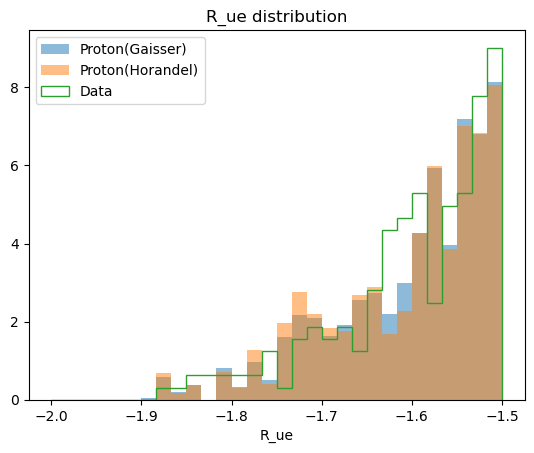

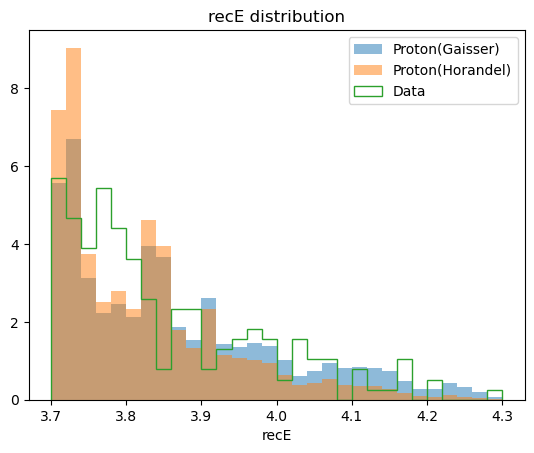

In [53]:

# # 对recE, R_ue, rec_theta, dr, Eage, rho40, compactness, pincness这几个column分布对比,density hist plot 4*2
# fig, axs = plt.subplots(4, 2, figsize=(10, 10))
# columns_to_plot = ['recE', 'R_ue', 'rec_theta', 'dr', 'Eage', 'rho40', 'compactness', 'pincness']
# for i, col in enumerate(columns_to_plot):
#     ax = axs[i//2, i%2]
#     ax.hist(one_day_df[col], bins=50, density=True, alpha=0.5, label='One Day Data')
#     ax.hist(pr_npz_df[col], bins=50, density=True, alpha=0.5, label='Proton Simulation')
#     ax.set_xlabel(col)
#     ax.set_title(col)
#     ax.legend()
# plt.tight_layout()
# plt.show()

CR_RUE_LOW=-1.9
CR_RUE_HIGH=-1.5
CR_RUE_LOW_PLOT=-2.0
pr_df_large_RueCR= pr_npz_df[(pr_npz_df['R_ue'] > CR_RUE_LOW) & (pr_npz_df['R_ue'] < CR_RUE_HIGH)]
one_day_df_large_RueCR= one_day_df[(one_day_df['R_ue'] > CR_RUE_LOW) & (one_day_df['R_ue'] < CR_RUE_HIGH)]

pr_gaisser_avarage = np.average(pr_df_large_RueCR['R_ue'], weights=pr_df_large_RueCR['gaisser_weight'])
pr_horandel_avarage = np.average(pr_df_large_RueCR['R_ue'], weights=pr_df_large_RueCR['horandel_weight'])
one_day_avarage = np.average(one_day_df_large_RueCR['R_ue'])
print(f"Proton(Gaisser) average R_ue: {pr_gaisser_avarage}")
print(f"Proton(Horandel) average R_ue: {pr_horandel_avarage}")
print(f"One Day Data average R_ue: {one_day_avarage}")
print(f'mc length: {len(pr_df_large_RueCR)}, one day data length: {len(one_day_df_large_RueCR)}')

bins=30
plt.hist(pr_df_large_RueCR['R_ue'], bins=bins,range=(CR_RUE_LOW_PLOT,CR_RUE_HIGH), weights=pr_df_large_RueCR['gaisser_weight'], density=True, alpha=0.5, label='Proton(Gaisser)')
plt.hist(pr_df_large_RueCR['R_ue'], bins=bins,range=(CR_RUE_LOW_PLOT,CR_RUE_HIGH), weights=pr_df_large_RueCR['horandel_weight'], density=True, alpha=0.5, label='Proton(Horandel)')
plt.hist(one_day_df_large_RueCR['R_ue'], bins=bins,range=(CR_RUE_LOW_PLOT,CR_RUE_HIGH),  density=True, alpha=1, histtype='step', label='Data')
plt.xlabel('R_ue')
plt.title('R_ue distribution')
# plt.yscale('log')
plt.legend()
plt.show()
# recE range : 3.7-4.3
plt.hist(pr_df_large_RueCR['recE'], bins=bins,range=(3.7,4.3), weights=pr_df_large_RueCR['gaisser_weight'], density=True, alpha=0.5, label='Proton(Gaisser)')
plt.hist(pr_df_large_RueCR['recE'], bins=bins,range=(3.7,4.3), weights=pr_df_large_RueCR['horandel_weight'], density=True, alpha=0.5, label='Proton(Horandel)')
plt.hist(one_day_df_large_RueCR['recE'], bins=bins,range=(3.7,4.3),  density=True, alpha=1, histtype='step', label='Data')
plt.xlabel('recE')
plt.title('recE distribution')
# plt.yscale('log')
plt.legend()
plt.show()

In [13]:
import numpy as np
import pandas as pd
import uproot
from xgboost import XGBRegressor

# --- 1. 配置参数 ---
BASE_PATH = "/data/home/zzh/data/Dataset_Filted/CosmicRay"
FILES = {
    "proton": "QF_Proton_addweight_rho_2.5e13_5.0e17_V3.root",
    "he":     "QF_He_addweight_rho_2.5e13_5.0e17_V3.root",
    "cno":    "QF_CNO_addweight_rho_2.5e13_5.0e17_V3.root",
    "fe":     "QF_Fe_addweight_rho_2.5e13_5.0e17_V3.root",
    "mgalsi": "QF_MgAlSi_addweight_rho_2.5e13_5.0e17_V3.root"
}

CUTS = (
    "rec_Eage > 0 and Redge > 0 and NuW3 > 0 and NpE3 > 250 "
    "and @theta_cut_low < rec_theta < @theta_cut_high"
)

# 阈值变量
r_cut_low, r_cut_high = 320, 420
theta_cut_low, theta_cut_high = np.deg2rad([10, 30])
log10TeV_low=3.7; log10TeV_high=4.3

# --- 2. 能量修正模型 ---
model = XGBRegressor();model._estimator_type = "regressor"
model.load_model("/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json")
import json
        
# 加载线性参数
with open("/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json", 'r') as f:
    lp = json.load(f)
intercept  = lp["intercept"]
coef_NuW3  = lp["coef"][0]
coef_theta = lp["coef"][1]

# --- 3. 核心处理函数 ---
def process_cosmic_ray(name, filename):
    with uproot.open(f"{BASE_PATH}/{filename}") as f:
        # 读取数据
        branches = ["E", "theta", "phi", "corex", "corey", "rec_x", "rec_y", 
                    "rec_theta", "rec_phi", "rec_Eage", "Redge", "NpE3", "NuM1", "NuW3", "weightGaisser", "weightHorandol"]
        df = f["Rec"].arrays(branches, library="pd")
        
        print(f"Processing {name}: Entries={len(df)}, Weights={df['weightGaisser'].sum():.2e}")

        # 1. 基础物理筛选
        df = df.query(CUTS).copy()
        
        # 2. 计算特征量
        df["R_ue"] = np.log10((1e-4 + df["NuM1"]) / (df["NpE3"]))
        df["r"] = np.hypot(df['rec_x'], df['rec_y']) # 比 sqrt(x^2+y^2) 更快
        
        # 3. 半径进一步筛选
        df = df[(df["r"] > r_cut_low) & (df["r"] < r_cut_high)]
        df['NuW3'] = np.log10(df['NuW3'])
        # 4. XGBoost 能量修正
        features = df[["NuW3", "rec_theta"]].values
        df["recE"] = model.predict(features) + intercept + coef_NuW3 * df['NuW3'] + coef_theta * df['rec_theta']
        
        print(f"     Finished {name}: Remaining Entries={len(df)}")
        return df[(df['recE']>log10TeV_low) & (df['recE']<log10TeV_high)]

# --- 4. 批量执行 ---
dfs = {name: process_cosmic_ray(name, path) for name, path in FILES.items()}
# 如果你需要解包到独立变量（虽然推荐直接用字典 dfs['proton']）
proton_df, he_df, cno_df, fe_df, mgalsi_df = dfs.values()
df_all_components = pd.concat(dfs.values(), ignore_index=True)
df_all_components['Eage'] = df_all_components['rec_Eage'] 


Processing proton: Entries=14217778, Weights=1.90e+02
     Finished proton: Remaining Entries=767187
Processing he: Entries=14210418, Weights=2.03e+02
     Finished he: Remaining Entries=525865
Processing cno: Entries=14218958, Weights=7.65e+01
     Finished cno: Remaining Entries=398519
Processing fe: Entries=14217887, Weights=7.40e+01
     Finished fe: Remaining Entries=330377
Processing mgalsi: Entries=14220016, Weights=3.57e+01
     Finished mgalsi: Remaining Entries=364106


In [18]:
mc_df_list = []
for name, df in dfs.items():
    temp_df = df.copy()
    temp_df['component'] = name  # 标记成分 (可选)
    mc_df_list.append(temp_df)

mc_total = pd.concat(mc_df_list, ignore_index=True)

for col in one_day_df.columns:
    one_day_df[col] = pd.to_numeric(one_day_df[col], errors='coerce')
    
one_day_df['rec_r'] = np.hypot(one_day_df['rec_x'], one_day_df['rec_y'])
mask = ((one_day_df['rec_r'] > r_cut_low) & (one_day_df['rec_r'] < r_cut_high) &
        (one_day_df['rec_theta'] > theta_cut_low) & (one_day_df['rec_theta'] < theta_cut_high) )
one_day_df_small = one_day_df[mask]

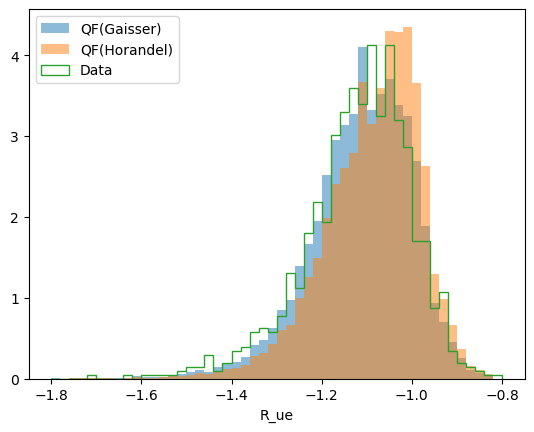

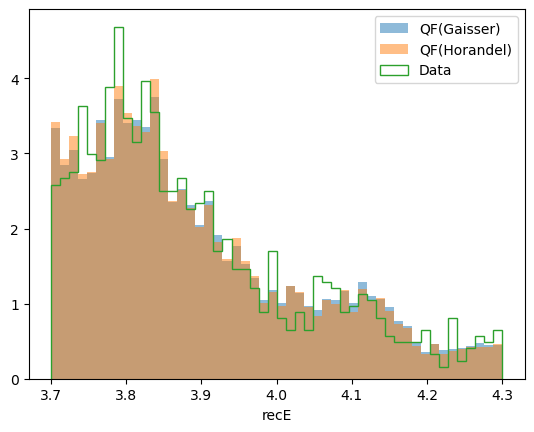

In [52]:
plt.hist(mc_total['R_ue'], bins=50, range=(-1.8, -0.8), density=True, weights=mc_total['weightGaisser'], alpha=0.5, label='QF(Gaisser)')
plt.hist(mc_total['R_ue'], bins=50, range=(-1.8, -0.8),density=True, weights=mc_total['weightHorandol'], alpha=0.5, label='QF(Horandel)')
plt.hist(one_day_df_small['R_ue'], bins=50, range=(-1.8, -0.8), histtype="step",density=True, alpha=1, label='Data')
plt.legend()
plt.xlabel('R_ue')
# plt.yscale('log')
plt.show()


# recE
plt.hist(mc_total['recE'], bins=50, range=(3.7, 4.3), density=True, weights=mc_total['weightGaisser'], alpha=0.5, label='QF(Gaisser)')
plt.hist(mc_total['recE'], bins=50, range=(3.7, 4.3),density=True, weights=mc_total['weightHorandol'], alpha=0.5, label='QF(Horandel)' )
plt.hist(one_day_df_small['recE'], bins=50, range=(3.7, 4.3), histtype="step", density=True, alpha=1, label='Data')
plt.legend()
plt.xlabel('recE')
plt.show()